# import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Load Dataset

In [2]:
df = pd.read_csv("Iris.csv")

print(df.head())
print(df.info())
print(df.describe())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB
None
               Id  SepalLength

# Data Cleaning

In [3]:
# Check null values
print(df.isnull().sum())

# Remove Id column
df.drop("Id", axis=1, inplace=True)

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


# Exploratory Data Analysis (EDA)

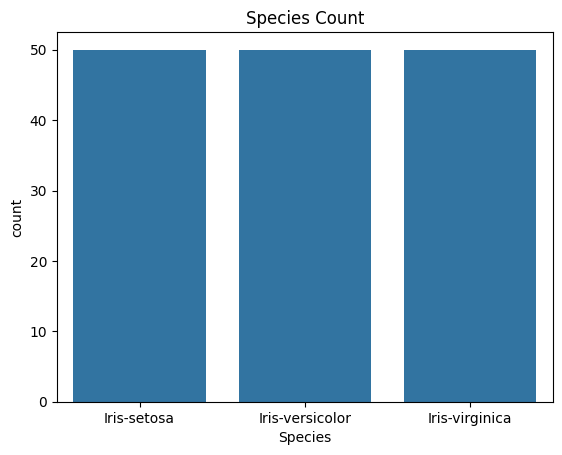

In [4]:
sns.countplot(x='Species', data=df)
plt.title("Species Count")
plt.show()

## Pairplot

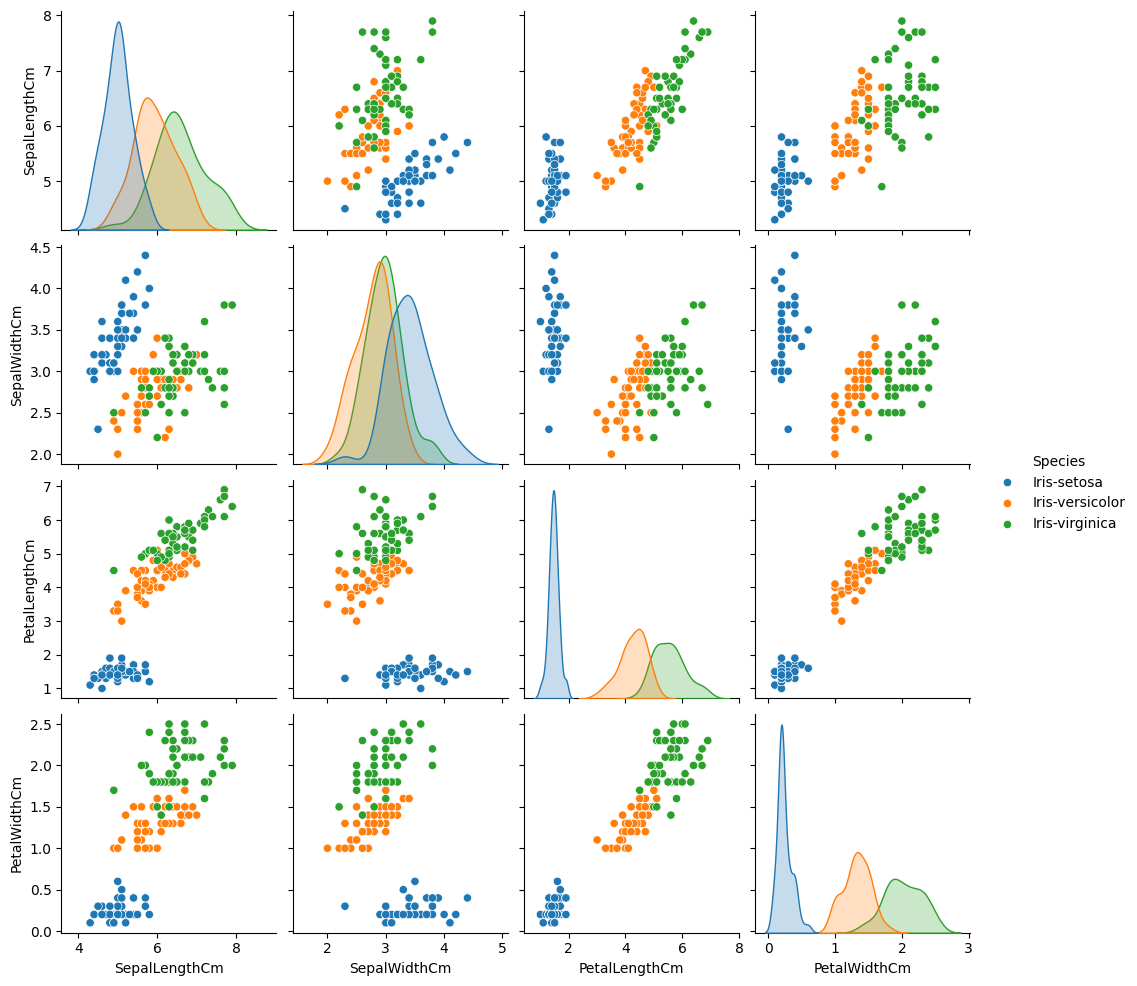

In [5]:
sns.pairplot(df, hue='Species')
plt.show()

## Heatmap

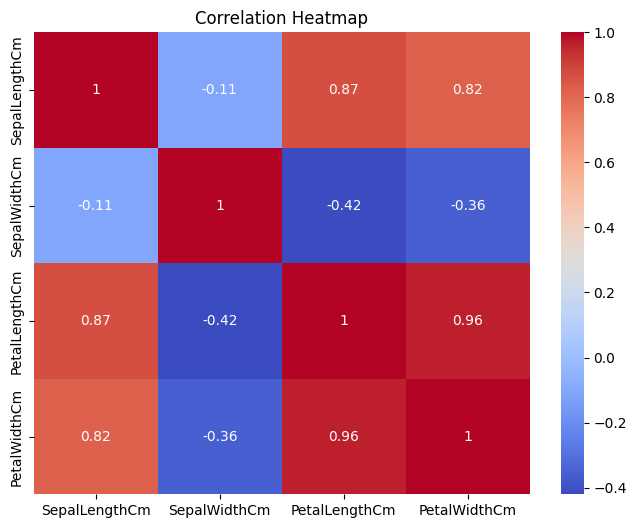

In [6]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Encode Target Variable

In [7]:
le = LabelEncoder()

df['Species'] = le.fit_transform(df['Species'])

print(df.head())

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  Species
0            5.1           3.5            1.4           0.2        0
1            4.9           3.0            1.4           0.2        0
2            4.7           3.2            1.3           0.2        0
3            4.6           3.1            1.5           0.2        0
4            5.0           3.6            1.4           0.2        0


#  Split Features and Target

In [8]:
X = df.drop("Species", axis=1)
y = df["Species"]

# Feature Scaling

In [9]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

# Train Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train Multiple Models

In [11]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 1.0


## KNN

In [12]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print("KNN Accuracy:",
      accuracy_score(y_test, knn_pred))

KNN Accuracy: 1.0


## Decision Tree

In [13]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 1.0


## Random Forest

In [14]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 1.0


## Support Vector Machine

In [15]:
svm = SVC()

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print("SVM Accuracy:",
      accuracy_score(y_test, svm_pred))

SVM Accuracy: 1.0


# Compare Accuracy

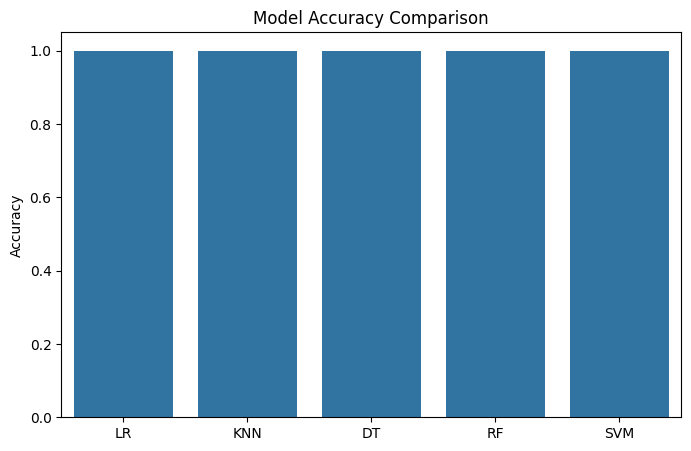

In [16]:
models = ['LR', 'KNN', 'DT', 'RF', 'SVM']

scores = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, knn_pred),
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, svm_pred)
]

plt.figure(figsize=(8,5))

sns.barplot(x=models, y=scores)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

## Confusion Matrix

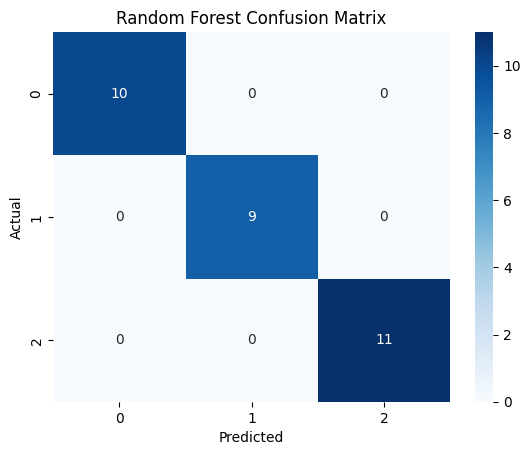

In [17]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Classification Report

In [18]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# Feature Importance

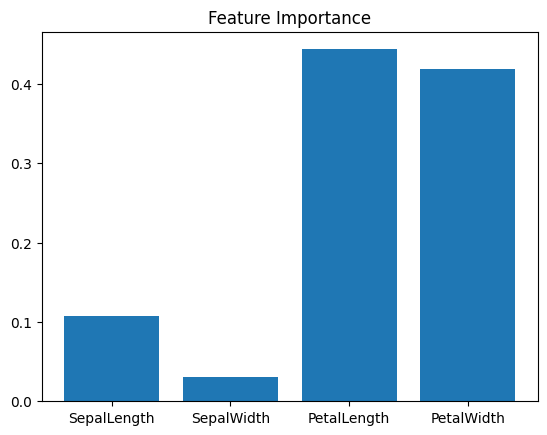

In [19]:
importance = rf.feature_importances_

features = X_train.shape[1]

plt.bar(range(features), importance)

plt.xticks(range(features),
           ['SepalLength',
            'SepalWidth',
            'PetalLength',
            'PetalWidth'])

plt.title("Feature Importance")

plt.show()

# Predict New Flower

In [20]:
sample = [[5.1, 3.5, 1.4, 0.2]]

sample = scaler.transform(sample)

prediction = rf.predict(sample)

print("Predicted Class:", prediction)

print("Flower Species:",
      le.inverse_transform(prediction))

Predicted Class: [0]
Flower Species: ['Iris-setosa']


C:\Users\Hp\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
